In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("student_dropout_data.csv")
df.sample(10)

,gender,age,attendance_pct,marks,homework_completion_pct,distance_to_school,Tution_fee_status,Transportation_fee_status,has_schlorship,has_transportation,dropout
9436,1,17,66.6,68.3,69.3,708.6,0,Not Applicable,0,0,No
1971,1,6,82.3,65.8,77.8,6843.5,0,Paid,0,1,No
13445,1,18,88.5,75.2,88.4,131.6,1,Paid,0,1,No
26150,1,10,53.2,43.9,59.6,288.9,0,Paid,0,1,No
7872,1,14,79.5,43.0,64.4,1086.5,1,Paid,0,1,Yes
15866,1,17,89.4,86.4,73.7,1808.9,1,Paid,0,1,No
11106,1,12,100.0,92.8,93.1,3520.9,1,Unpaid,0,1,No
4549,1,12,66.2,48.4,67.4,5730.1,0,Paid,0,1,No
17559,1,11,89.1,67.3,78.3,516.7,1,Not Applicable,0,0,Yes
9483,1,8,57.1,57.2,63.8,3609.5,1,Paid,0,1,Yes


In [33]:
df['gender'].value_counts()

gender
0    15648
1    14352
Name: count, dtype: int64

In [34]:
df['Transportation_fee_status'].value_counts()

Transportation_fee_status
Not Applicable    16598
Paid               9358
Partial            2701
Unpaid             1343
Name: count, dtype: int64

In [35]:
df['has_transportation'].value_counts()

has_transportation
0    16598
1    13402
Name: count, dtype: int64

<Axes: xlabel='age'>

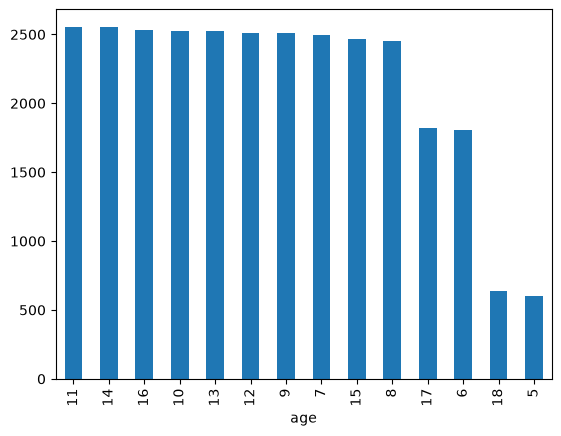

In [36]:
df['age'].value_counts().plot(kind='bar')

In [37]:
def dropout_func(x):
    if x == 'Yes':
        return 1
    else:
        return 0
df['dropout'] = df['dropout'].apply(dropout_func)


In [38]:
df['dropout'].value_counts()

dropout
0    22354
1     7646
Name: count, dtype: int64

In [39]:
df.shape

(30000, 11)

In [40]:
df['has_schlorship'].value_counts()

has_schlorship
0    24569
1     5431
Name: count, dtype: int64

In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Transportation_fee_status'] = le.fit_transform(df['Transportation_fee_status'])


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gender                     30000 non-null  int64  
 1   age                        30000 non-null  int64  
 2   attendance_pct             30000 non-null  float64
 3   marks                      30000 non-null  float64
 4   homework_completion_pct    30000 non-null  float64
 5   distance_to_school         30000 non-null  float64
 6   Tution_fee_status          30000 non-null  int64  
 7   Transportation_fee_status  30000 non-null  int64  
 8   has_schlorship             30000 non-null  int64  
 9   has_transportation         30000 non-null  int64  
 10  dropout                    30000 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 2.5 MB


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.describe()

,gender,age,attendance_pct,marks,homework_completion_pct,distance_to_school,Tution_fee_status,Transportation_fee_status,has_schlorship,has_transportation,dropout
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.478400,11.520167,76.432300,65.312847,68.685587,2290.860533,0.751400,0.626300,0.181033,0.446733,0.254867
std,0.499542,3.505967,12.713864,13.883360,14.034724,2174.616488,0.432209,0.826279,0.385052,0.497163,0.435794
min,0.000000,5.000000,18.200000,0.000000,11.500000,100.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,67.800000,56.000000,58.900000,731.575000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,12.000000,76.800000,65.400000,68.400000,1630.850000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,14.000000,85.500000,75.000000,78.400000,3139.425000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,18.000000,100.000000,100.000000,100.000000,20000.000000,1.000000,3.000000,1.000000,1.000000,1.000000


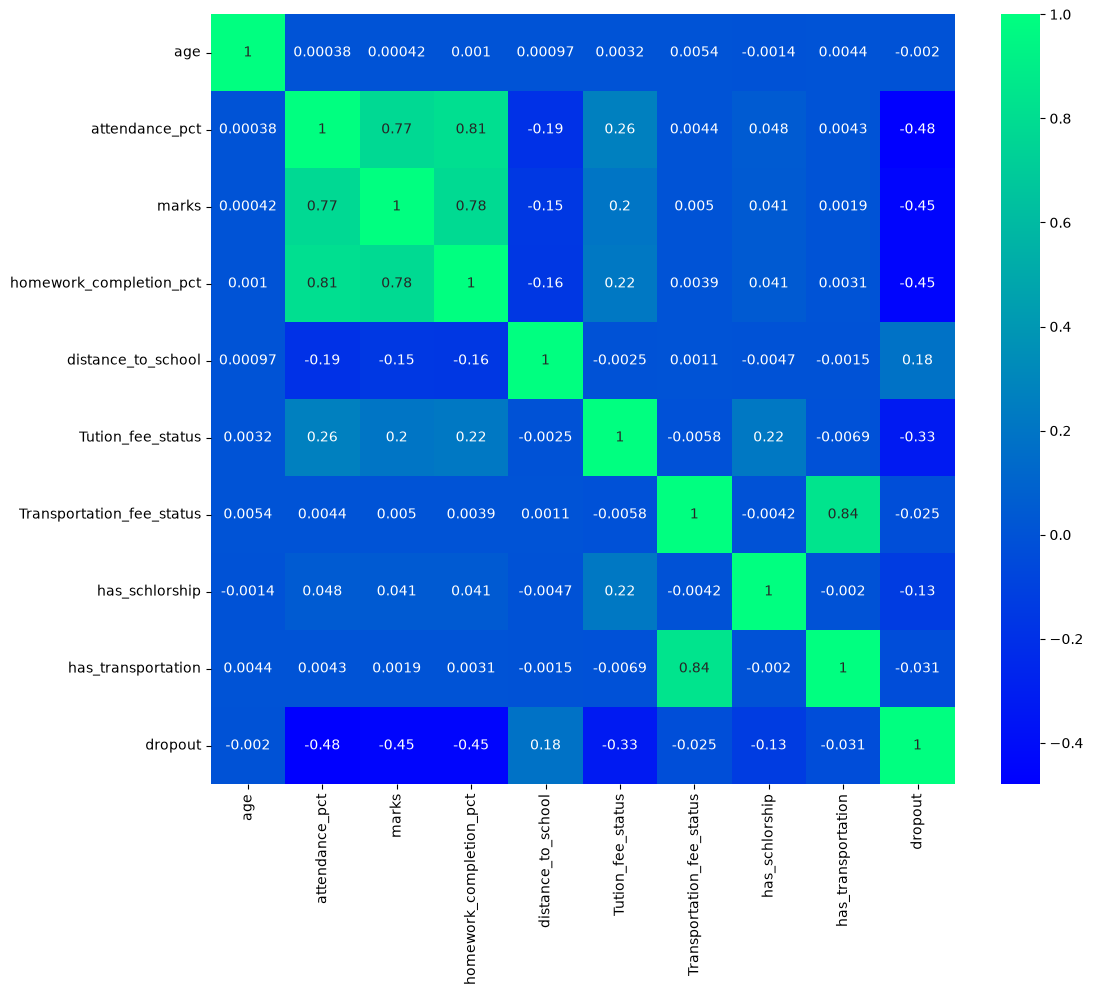

In [45]:
corr=df.drop(columns=['gender']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='winter')
plt.show()

In [46]:
df.isnull().sum()

gender                       0
age                          0
attendance_pct               0
marks                        0
homework_completion_pct      0
distance_to_school           0
Tution_fee_status            0
Transportation_fee_status    0
has_schlorship               0
has_transportation           0
dropout                      0
dtype: int64

In [47]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["dropout"])
y = df["dropout"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31,stratify=y
)

In [48]:

from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=95,
    learning_rate=0.12624300895299176,
    max_depth=11,
    min_child_weight=12,
    subsample=0.9093351843520031,
    colsample_bytree=0.38044786913548584,
    gamma=7.3923835659261545,
    reg_alpha=6.708529169222408,
    reg_lambda=8.197595043617294,

    objective="binary:logistic",
    eval_metric="logloss",
    random_state=31,
    n_jobs=-1,
)

from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_transformer = Pipeline([
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
],remainder='passthrough')
pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=5
        )),
        ("model", xgb)
    ])
pipe.fit(X_train,y_train)
preds=pipe.predict(X_test)
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      6706
           1       0.57      0.72      0.63      2294

    accuracy                           0.79      9000
   macro avg       0.73      0.77      0.74      9000
weighted avg       0.81      0.79      0.80      9000

[[5460 1246]
 [ 648 1646]]


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
prob = pipe.predict_proba(X_test)[:, 1]
y_preds = (prob >= 0.513).astype(int)
acc = accuracy_score(y_test, y_preds)
p = precision_score(y_test, y_preds)
r = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
roc_auc = roc_auc_score(y_test, prob)
print(acc)
print(r)
print(p)
print(f1)
print(roc_auc)

0.7934444444444444
0.7035745422842197
0.5778732545649838
0.6345586789856497
0.8507874378135002


In [50]:
import shap
import pandas as pd
student = X_test.iloc[[2]]
preprocessor = pipe.named_steps["preprocessor"]
xgb_model = pipe.named_steps["model"]
student_transformed = preprocessor.transform(student)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(student_transformed)
feature_names = preprocessor.get_feature_names_out()
contributions = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values.values[0],
})
positive = (
    contributions[contributions["shap_value"] > 0]
    .sort_values("shap_value", ascending=False)
)
probability = pipe.predict_proba(student)[0, 1]
print("Student")
print("----------------------")
print(f"Dropout probability: {probability:.2%}")
if len(positive) > 0:
    main_factor = positive.iloc[0]
    print("Main factor:", main_factor["feature"])
    print("SHAP contribution:", main_factor["shap_value"])
else:
    print("No features increased the dropout prediction.")

Student
----------------------
Dropout probability: 53.17%
Main factor: num__attendance_pct
SHAP contribution: 0.6500961


In [51]:
import pickle

with open("dropout_model.pkl", "wb") as f:
    pickle.dump("dropout_model" , f)

In [52]:
%pip install scikit-learn==1.9.0

Note: you may need to restart the kernel to use updated packages.


In [53]:
import sklearn
print(sklearn.__version__)

1.9.0


In [54]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train,
)

candidate_settings = [
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "scale_pos_weight": 1.0},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.03, "scale_pos_weight": 1.0},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.03, "scale_pos_weight": 1.0},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.03, "scale_pos_weight": 1.5},
]

validation_thresholds = np.arange(0.20, 0.61, 0.01)
results = []

for settings in candidate_settings:
    candidate_model = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", XGBClassifier(
            **settings,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
        )),
    ])

    candidate_model.fit(X_fit, y_fit)
    validation_probabilities = candidate_model.predict_proba(X_validation)[:, 1]
    threshold_scores = [
        f1_score(y_validation, validation_probabilities >= threshold)
        for threshold in validation_thresholds
    ]
    best_index = int(np.argmax(threshold_scores))

    results.append({
        "settings": settings,
        "threshold": float(validation_thresholds[best_index]),
        "f1": float(threshold_scores[best_index]),
    })

best_result = max(results, key=lambda result: result["f1"])
best_threshold = best_result["threshold"]

xgb_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(
        **best_result["settings"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
    )),
])
xgb_model.fit(X_train, y_train)

print("Best settings:", best_result["settings"])
print(f"Selected threshold: {best_threshold:.2f}")
print(f"Validation F1: {best_result['f1']:.4f}")

Best settings: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'scale_pos_weight': 1.0}
Selected threshold: 0.30
Validation F1: 0.6540


In [55]:
import joblib

model_artifact = {
    "model": xgb_model,
    "threshold": best_threshold,
}

joblib.dump(
    model_artifact,
    "student_prediction_model.pkl"
)

print("Model saved.")

Model saved.


In [56]:
import joblib

joblib.dump(
    {
        "X_test": X_test,
        "y_test": y_test
    },
    "test_data.pkl"
)

print("Test data saved.")

Test data saved.
